### Hello! Welcome to Baby's First Microlensing Tutorial, by a Baby. 

This tutorial walks you through all the mise en place (the chopping vegetables of microlensing), event detection, anomaly detection, and event fitting, one step at a time, for a single event in the Beginner Tier of the Roman Microlensing Data Challenge. This notebook is meant to be run in the Roman Nexus environment.

I don't cover the MCMC stage here, at least not yet. 

#### Baby's first installs and imports

In [1]:
# %pip install -U microlens_submit # only needed to submit. if you do this you are not a baby
%pip install -U RTModel==3.1 # Valerio Bozza's RTModel for event fitting; alternatives include Radek Poleski's MulensModel and Dave Bennet's eusunghong
%pip install -U jacscanomaly # Kansuke Nunota's code for anomaly finding
%pip install -U microjax # jacscanomaly dependency


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Install aethra for event detection: this is still in development by Katie Vandorou https://github.com/rges-pit/aethra/tree/main

##### Until it's pip installable, you must run the cell below as-is

In [2]:
### this block is from the GitHub README
!git clone https://github.com/rges-pit/aethra.git
%cd aethra
%pip install -e ".[parquet]"
#%pip install -e .
#%cd ..

### this block is from Katie, because for some reason this ad hoc install is confusing the Nexus environment about where to point
import sys
LOCAL = '/teams/mldc-ipacpeople/nexus-notebooks/notebooks/aethra/src'

sys.path.insert(0, LOCAL)
for m in [k for k in sys.modules if k == "aethra" or k.startswith("aethra.")]:
    del sys.modules[m]

import aethra
assert aethra.__file__.startswith(LOCAL), f"still importing {aethra.__file__}"
print("using:", aethra.__file__)

fatal: destination path 'aethra' already exists and is not an empty directory.
/teams/mldc-ipacpeople/nexus-notebooks/notebooks/aethra
Obtaining file:///teams/mldc-ipacpeople/nexus-notebooks/notebooks/aethra
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for aethra (pyproject.toml) ... done
  Created wheel for aethra: filename=aethra-0.1.0-0.editable-py3-none-any.whl size=6272 sha256=dff00f3cc07bd0341ec178bdeb480fff5494ee7dc1b7d5d37fb3829a1573fbdd
  Stored in directory: /tmp/pip-ephem-wheel-cache-sgjh7ian/wheels/4a/96/bd/77771e98dadff18a0272ab935cacd196a006861e588c985afb
Successfully built aethra
  Attempting uninstall: aethra
    Found existing installation: aethra 0.1.0
    Uninstalling aethra-0.1.0:
      Successfully uninstalled aethra-0.1.0

[notice] A new release of pip is available: 25.3 -> 26.2
[noti

In [3]:
#import aethra
from aethra import load_config, load_and_run

In [4]:
# system imports
import os
import time
import sys
from pathlib import Path

# data access imports
from huggingface_hub import hf_hub_download
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# display imports
from IPython.display import HTML

# multiprocessing imports
import multiprocessing as mp
from multiprocessing.pool import ThreadPool

# data challenge imports
import microlens_submit
#import MulensModel
import emcee
#from pyLIMA.pyLIMASS import SourceLensProbabilities
import RTModel

# data analysis/visualization imports
import numpy as np
import matplotlib.pyplot as plt

# for event detection (the old version, before aethra)
#from eventfinder import load_and_run, _read_table_file, run_pipeline_from_dataframe
# for anomaly detection
from jacscanomaly import CandidateCriteria, Finder, FinderConfig

#### IMPORTANT: Who are you?

In [5]:
event_data_me = 'event_data_chris' # please change 'chris' to your name, otherwise you will overwrite my work

#### Baby's first data inspection

Let's grab our data from the huggingface data lake. Each tier has one parquet file and is described in its corresponding docs page, e.g., https://huggingface.co/datasets/RGES-PIT/Beginner

In [6]:
TIER = "Beginner" # change to Experienced or ML if you want to not be a baby
REPO_ID = f"RGES-PIT/{TIER}" 

FILENAME = f"RMDC26_{TIER}_Tier_test.parquet"  # "_test" tells hugging face this is not a machine learning training set.
local_data_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, repo_type="dataset") # retrieve parquet file from huggingface
lc_data_all = pd.read_parquet(local_data_path) 
print(local_data_path)
print(lc_data_all)
print(lc_data_all.columns)
print(lc_data_all['name'])

# for convenience, enrich with a column that's BJD-2450000
lc_data_all['bjd-2450000'] = lc_data_all['bjd'] - 2450000

/home/mldc-ipacpeople-admin/.cache/huggingface/hub/datasets--RGES-PIT--Beginner/snapshots/3d091e68f83662a843c9a5ef78b913c1b0e30848/RMDC26_Beginner_Tier_test.parquet
                  name     l_deg     b_deg      ra_deg    dec_deg  \
0        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
1        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
2        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
3        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
4        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
...                ...       ...       ...         ...        ...   
9230043  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   
9230044  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   
9230045  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   
9230046  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   
9230047  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   

      

In [7]:
### if you are an admin
root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople'
### if you are not an admin
# root_dir = '/teams/mldc-ipacpeople'

# 3 Roman filters: 
# F146 is the high-cadence (12 min) wide filter
# F087 (or Z087) is ~12 hr cadence NIR filter
# F213 (or K213) is ~12 hr cadence, farther into the IR
filters = ['F087', 'F146', 'F213'] 

In [8]:
### in my main notebooks, I do the following all in one loop. For this tutorial, though, we are breaking it down to one event.

# pick out event/light curve
EVENT_ID = 'RMDC26_000001' # first event in the Beginner Tier; first event in the Experienced Tier is RMDC26_000189
lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID]
actual_id = EVENT_ID.split("_", 1)[1]

#### Baby's first RTModel mise en place

This part is the most discouraging because there's so much arcane knowledge required just to set up RTModel to do the event fitting. RTModel is extremely particular about having the right directory structure to run the event. There's no science here, only suffering. 

Please do not waste time in confusion if something breaks here, and just ping me on Slack or email instead.

In [9]:
# create event directory in the format RTModel wants
new_event_dir = root_dir + '/' + event_data_me + '/event_' + actual_id
try:
    os.mkdir(new_event_dir)
except Exception as e:
    pass
# create /Data/ directory in your event directory. This is necessary for RTModel, which is very picky about your event directory layout!
try:
    os.mkdir(new_event_dir + '/Data/')
except Exception as e:
    pass

##### The /Data/ directory needs to be populated with five files in order for RTModel to properly run:
-  3 .dat files corresponding to each of the the 3 filters
-  a file with the event coordinates
-  a file with limb darkening parameters

DO NOT CHANGE. Except plotting, you can change the plotting.

##### The .dat files

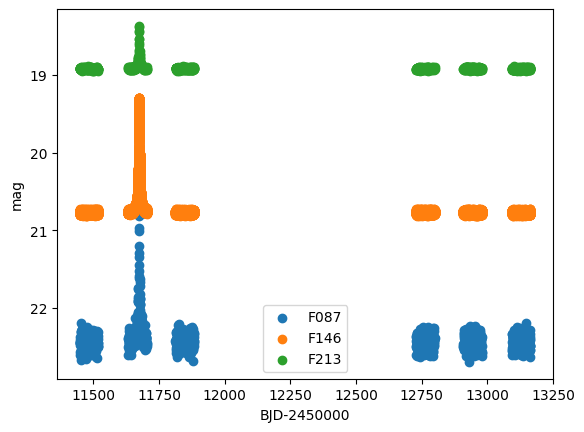

In [10]:
# each filter should be converted to a .dat file with the following header: # Mag err HJD-2450000
# furthermore, RTModel is particular about filename structures: .dat files should end with the correct satelllite suffix
# name schematics follow the schematic from Stela Ishitani Silva's post on WG3 Confluence page
# https://rgespit.atlassian.net/wiki/spaces/RPTH/pages/154828801/RTModel+v2.4+Runs+for+the+2371+Representative+Sample+Lightcurves
for filt in filters:
    lc_data_filt = lc_data.loc[lc_data['filt']==filt]#[time_mask]
    lc_data_dat = pd.DataFrame({'Mag': lc_data_filt['mag'], 'err': lc_data_filt['mag_err'], 'HJD-2450000': lc_data_filt['bjd-2450000']})
    if filt=='F087':
        dat_filepath = new_event_dir + '/Data/RomanZ087sat2.dat'
    elif filt=='F146':
        dat_filepath = new_event_dir + '/Data/RomanW146sat1.dat'
    elif filt=='F213':
        dat_filepath = new_event_dir + '/Data/RomanK213sat3.dat'
    with open(dat_filepath, "w", encoding="utf-8") as f:
        f.write("# Mag err HJD-2450000\n")
        lc_data_dat.to_csv(f, sep=' ', header=None, index=False)

    plt.scatter(lc_data_filt['bjd-2450000'], lc_data_filt['mag'], label=filt)
plt.gca().yaxis.set_inverted(True)
plt.ylabel('mag')
plt.xlabel('BJD-2450000')
plt.legend()
plt.show()

##### Event coordinates

In [11]:
# add coordinates in Data/ dir too     
coords = SkyCoord(ra=lc_data_filt['ra_deg'].values[0]*u.degree, dec=lc_data_filt['dec_deg'].values[0]*u.degree, frame='icrs')
ra_hms = coords.ra.to_string(unit=u.hourangle, sep=':', pad=True)
dec_dms = coords.dec.to_string(sep=':', pad=True)
coord_filepath = new_event_dir + '/Data/event.coordinates'
with open(coord_filepath, "w", encoding="utf-8") as cf:
    cf.write(f"{ra_hms} {dec_dms}")

Limb darkening

In [12]:
# add limb darkening file in Data/
limb_dark_filepath = new_event_dir + '/Data/LimbDarkening.txt'
with open(limb_dark_filepath, "w", encoding="utf-8") as ld:
    ld.write("0.33 \n0.4532 \n0.251")

#### Baby's First Event Detection

*Feel free to skip this if you are concerned only about event fitting, especially because the Beginner Tier events don't contain any false positives.*

Basically this step is to search the light curve for a candidate and fit a PSPL (point source point lens) event -- that is, a big slow bump created by a lens star crossing in front of the source star. The PSPL fit returns for us three parameters that feed into the event modeling: t0, u0, and tE. 

- t0: time of maximum magnification
- u0: impact parameter (distance in Einstein ring radii of the source-lens separation in the sky at t0)
- tE: Einstein crossing time (event duration; the full-width half-maximum of the PSPL, basically)

If you want to move straight to event fitting, you can do this without these initial parameters, and it is worth testing to see how much of a difference this makes.

In [13]:
# https://github.com/rges-pit/aethra
# there's a more basic way of setting the config (see aethra's README), but the config file in the following line is Katie-approved, so we'll use that
aethra_config = load_config(root_dir+"/config/aethra_config.yaml") # courtesy of Katie Vandorou; DO NOT CHANGE FILE CONTENTS

results_df = load_and_run(lc_data, aethra_config)
#candidates = results[results["is_candidate"]]

# ── Summary ───────────────────────────────────────────────────────────────────
n = len(results_df)
print(f"\nPipeline complete — {n} object(s) processed.")
print(f"  veto_periodic:   {results_df['veto_periodic'].sum()}")
print(f"  veto_recurrent:  {results_df['veto_recurrent'].sum()}")
print(f"  veto_chromatic:  {results_df['veto_chromatic'].sum()}")
print(f"  is_variable_star:{results_df['is_variable_star'].sum()}  (scan_candidate + any veto)")
print(f"  is_candidate:    {results_df['is_candidate'].sum()}")
print(f"  is_ffp_candidate:{results_df['is_ffp_candidate'].sum()}")

### this is logic for proceeding to next event in the loop if aethra fails to find a bound or free-floating planet candidate; relevant for experienced+ tiers
#if (results_df['is_candidate'].sum()==0) & (results_df['is_ffp_candidate'].sum()==0):
#    continue # skip to next event 

t0_fit = results_df['t0_fit'].iloc[0]
u0_fit = results_df['u0_fit'].iloc[0]
tE_fit = results_df['tE_fit'].iloc[0]
print("t0: ", t0_fit)
print("u0: ", u0_fit)
print("tE: ", tE_fit)

  49,096 rows, columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'mag', 'mag_err', 'extinction', 'obs_x', 'obs_y', 'obs_z', 'saturation_flag', 'bjd-2450000']

Pipeline complete — 1 object(s) processed.
  veto_periodic:   0
  veto_recurrent:  0
  veto_chromatic:  0
  is_variable_star:0  (scan_candidate + any veto)
  is_candidate:    1
  is_ffp_candidate:0
t0:  11674.391296790447
u0:  0.02656700037831565
tE:  22.52058795090023


#### Baby's First Anomaly Detection

*Feel free to also skip this step and go straight to event fitting if you want. Note that MSOS isn't doing this step either. (Instead, they go from Event Detection to fitting one model at a time in increasing complexity, until they reach some chisq improvement threshold. Which we could also attempt.)*

Now that we have our PSPL, let's see if there's a planet around the lens star. We will use jacscanomaly to fit a suite of anomaly templates (upward spike; dip; crown-shaped thingy denoting a caustic crossing) to search for anomalies and identify the planet's t0, which is what we're actually interested in for the model fitting stage.

**First, jacscanomaly gets confused if you feed in multiple filters' worth of data. Which makes sense -- microlensing is achromatic (this is one of aethra's checks). As a rule, let's choose F146 because that's the high-cadence filter.**

In [14]:
filter_mask = lc_data["filt"] == 'F146'
lc_data_filter_mask = lc_data[filter_mask]
time = np.array(lc_data_filter_mask["bjd-2450000"])#[time_mask & filter_mask])
mag = np.array(lc_data_filter_mask["mag"])#[time_mask & filter_mask])
magerr = np.array(lc_data_filter_mask["mag_err"])#[time_mask & filter_mask])

**Now we can set up jacscanomaly.** All search is heuristic to some extent. This is where we choose our delta chisq thresholds, how many peaks to consider, how to treat data gaps, etc.

In [15]:
criteria = CandidateCriteria(
    min_dchi2=20.0, 
    min_n_eff=2.0,
    #min_n_contrib=2,
    #max_peak_frac=0.8,
)
jacscanomaly_config = FinderConfig(
    fitter_kind="pspl",
    candidate_criteria=criteria, # candidate_criteria=CandidateCriteria(min_n_eff=2.0)
    gap=150.0 # default is 50. gap between seasons is ~half a year, though
)
finder = Finder(jacscanomaly_config)

**Run jacscanomaly and report outcome**

In [16]:
# initial guess is from aethra
p0 = np.array([t0_fit, tE_fit, u0_fit])  # t0, tE, u0

# actually run the anomaly finder. Make sure you're distinguishing between magnitude and flux. Beginner tier uses mag; experienced+ tiers use flux.
result = finder.run(time, mag, magerr, p0, data_kind="mag")
result.print_summary()
result_summary = result.summary_table()
print(result_summary)

# grab relevant variables
t0_fit_best = result_summary['best_t0'].values[0]
print("t0_fit_best: ", t0_fit_best)
best_score = result_summary['best_score'].values[0]
print("best score: ", best_score)

# this is where I skip to the next event, if jacscanomaly finds nothing
if best_score < 10:
    print("does not pass score threshold of 10")


=== jacscanomaly summary ===
points      : 46208
seasons     : 2
grid total  : 682857
clusters    : 1274
chi2 / dof  : 1.013

=== best candidate ===
t0          : 11673.126736
teff        : 0.399549
dchi2       : 362.527
score       : 87.554

=== quality ===
n_window    : 267
n_contrib   : 0
n_eff       : 97.871
peak_frac   : 0.026
rho1        : 0.323
longest_run : 0
   n_points  n_seasons  n_clusters  n_grid_total  chi2_dof  has_best  \
0     46208          2        1274        682857  1.013131      True   

        best_t0  best_teff  best_dchi2  best_score  best_score_n_reference  \
0  11673.126736   0.399549  362.526589   87.553891                      10   

   best_n_window  best_n_contrib  best_n_eff  best_peak_frac  best_rho1  \
0            267               0   97.870915         0.02642   0.322534   

   best_longest_run  
0                 0  
t0_fit_best:  11673.12673551235
best score:  87.55389128117321


#### Baby's first microlensing event plot(s)

Let's plot aethra and jacscanomaly's t0s on top of where they think the event is.

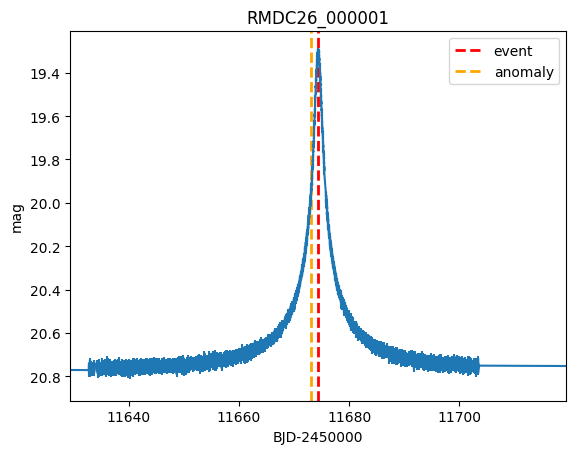

In [17]:
plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['mag'], lc_data_filter_mask['mag_err'], )
plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
plt.axvline(x=t0_fit_best, color='orange', linestyle='--', linewidth=2, label='anomaly')
plt.gca().yaxis.set_inverted(True)
plt.xlim([t0_fit - 2*tE_fit, t0_fit + 2*tE_fit]) # I picked 2*tE as the tolerance here because tE is ~22 days, and 4*22 spans a whole season. No reason to go wider than that.
plt.ylabel('mag')
plt.xlabel('BJD-2450000')
plt.title(f"{EVENT_ID}")
plt.legend()
plt.show()

Clearly, we're in the ballpark. Aethra for sure finds the PSPL event, but we're going to need to zoom in to see whether we found the anomaly. Let's do 0.2*tE on either side, which spans around 8 days.

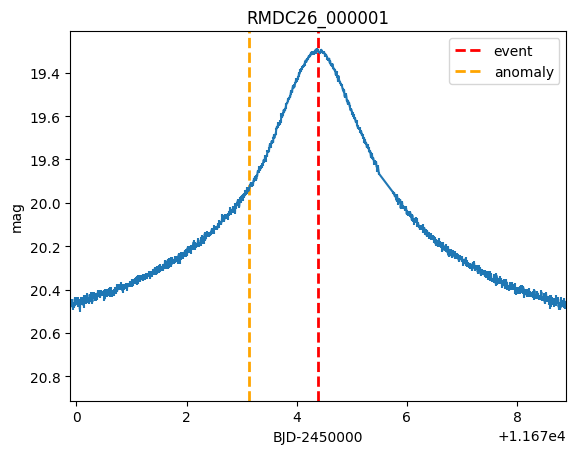

In [18]:
plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['mag'], lc_data_filter_mask['mag_err'], )
plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
plt.axvline(x=t0_fit_best, color='orange', linestyle='--', linewidth=2, label='anomaly')
plt.gca().yaxis.set_inverted(True)
plt.xlim([t0_fit - 0.2*tE_fit, t0_fit + 0.2*tE_fit])
plt.ylabel('mag')
plt.xlabel('BJD-2450000')
plt.title(f"{EVENT_ID}")
plt.legend()
plt.show()

Must be a small anomaly huh? Enhance! Let's let go of the PSPL peak and search a tight window around the supposed anomaly peak, say, 0.02*tE on either side.

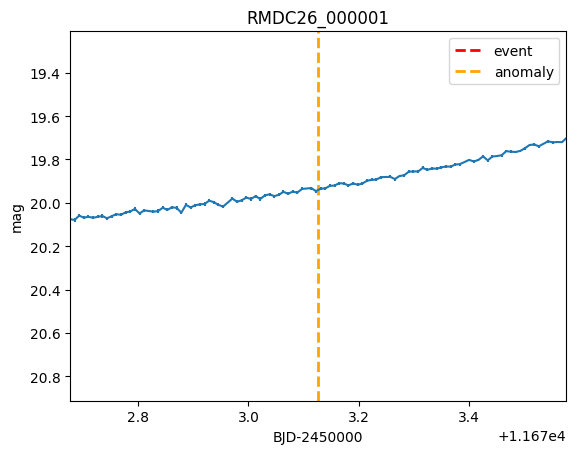

In [19]:
plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['mag'], lc_data_filter_mask['mag_err'], )
plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
plt.axvline(x=t0_fit_best, color='orange', linestyle='--', linewidth=2, label='anomaly')
plt.gca().yaxis.set_inverted(True)
plt.xlim([t0_fit_best - 0.02*tE_fit, t0_fit_best + 0.02*tE_fit]) # note the first variable is the anomaly peak, not the PSPL peak
plt.ylabel('mag')
plt.xlabel('BJD-2450000')
plt.title(f"{EVENT_ID}")
plt.legend()
plt.show()

We were scammed! (jk)

But it's not called jacscamnomaly for a reason. We just needed to do good enough for RTModel to start in the right place. We'll verify this in the next section, but for now, I actually know the right answer for this particular event, so let's zoom in on the actual anomaly, which is on the other side of the PSPL peak!

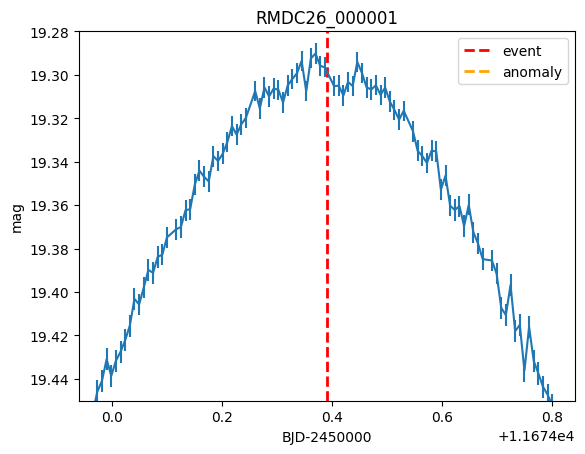

In [20]:
plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['mag'], lc_data_filter_mask['mag_err'], )
plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
plt.axvline(x=t0_fit_best, color='orange', linestyle='--', linewidth=2, label='anomaly')
plt.gca().yaxis.set_inverted(True)
plt.xlim([t0_fit - 0.02*tE_fit, t0_fit + 0.02*tE_fit])
plt.ylim([19.45, 19.28]) # this was not even evident until I zoomed in along the y axis as well...pain
plt.ylabel('mag')
plt.xlabel('BJD-2450000')
plt.title(f"{EVENT_ID}")
plt.legend()
plt.show()

If at this point you are about to crash out...actually go for it, you're a baby after all! 

Then after crashing out, you can start fitting the event using RTModel.

#### Baby's First Event Fitting

There are several model fitting codes out there for microlensing. The main four are:
- RTModel: used by PIT and MSOS. Fast, exhaustive. Finicky to set up and less effective at fitting lower mass exoplanets. See Bozza+24 (https://www.aanda.org/articles/aa/pdf/2024/08/aa50450-24.pdf) and https://github.com/valboz/RTModel
- eesunhong: uses initial condition grid search (ICGS), which makes it slower but more effective at fitting more complicated and lower signal events, including lower mass exoplanets. See https://eesunhong.readthedocs.io/en/latest/index.html
- MulensModel: most pedagogically friendly, with extensive documentation. It's what y'all used during the Sagan Summer Workshop! See Poleski+Yee 2019 (https://ui.adsabs.harvard.edu/abs/2019A&C....26...35P/abstract) and https://rpoleski.github.io/MulensModel/
- pyLIMA: also used by MSOS. Also fast. Really the only reason I use RTModel over pyLIMA is because both codes use VBMicrolensing to generate light curves for the modeling stage, and Valerio wrote both RTModel and VBMicrolensing, so I wanted to keep things in the same cinematic universe. See Bachelet+19 (https://ui.adsabs.harvard.edu/abs/2019ascl.soft06022B/abstract) and https://github.com/ebachelet/pyLIMA

**Instantiate an RTModel object and set up its configuration.**

In [21]:
rtm = RTModel.RTModel(new_event_dir) # if I do rtm.run(), this argument is empty (spoiler: we're not doing rtm.run()
rtm.set_satellite_dir(root_dir + '/satellitedir')
rtm.config_Reader(otherseasons=-1) # throw away all other seasons; this is reasonable because seasons are separated by ~half a year
rtm.config_InitCond(usesatellite = 1) # 1: space-based; 0: ground-based
rtm.Reader()
rtm.InitCond()

*********************
****   RTModel   ****
*********************
Event name: /teams/mldc-ipacpeople/event_data_chris/event_000001
Number of processors: 32
- Launching: Reader
  Pre-processing data...
  OK
- Launching: InitCond
  Setting initial conditions...
Peaks:  11674.4800  11673.9100  
  OK


There are two main ways to run RTModel: rtm.run(), which is a quick, hands-free way to kick-off RTModel's exhaustive model search, and what we're about to do instead, which allows us to feed in input parameters from aethra and jacscanomaly. It'd be worthwhile to evaluate the performance differences (in terms of speed, and in terms of correctness) between the two methods.

In [ ]:
### normally, I'd do rtm.run(), but if I want to feed in initial parameters, I need to run each model category manually, starting with PS
# rtm.run(root_dir + '/event_data_chris/event_'+EVENT_ID[-6:])

This is the second method: kick off RTModel with a PSPL fit with the initial parameters, and then spam launch_fits() and ModelSelector() for each model archetype. The model archetypes can be found in full detail here: https://github.com/valboz/RTModel/blob/main/docs/ModelCategories.md 

*Note: This also allows us to do things the MSOS way: try models of increasing complexity until we reach some delta chisq threshold and stop, so that we don't waste our time trying unnecessarily complex models. The risk is that since the likelihood space can get complicated, we may often find ourselves in local minima.*

The cell below is interrupted because I wrote this tutorial while on the Small Server. Don't waste your time running event modeling on a small server. Do this on a medium or large server!

In [48]:
rtm.LevMar('PSmyfit', parameters = [u0_fit, tE_fit, t0_fit, 0.001]) # u0, tE, t0, rho*, where rho* is fiducial, from Bozza+24
rtm.launch_fits('PS')
rtm.ModelSelector('PS')
rtm.launch_fits('PX') # PSPL w/parallax
rtm.ModelSelector('PX')
rtm.launch_fits('BS') # 2S1L
rtm.ModelSelector('BS')
rtm.launch_fits('BO') # 2S1L w/xallarap
rtm.ModelSelector('BO')
rtm.launch_fits('LS') # 1S2L
rtm.ModelSelector('LS')
rtm.launch_fits('LX') # 1S2L w/parallax
rtm.ModelSelector('LX')
rtm.launch_fits('LO') # 1S2L w/circular orbital motion
rtm.ModelSelector('LO')
# there's also:
# LK: 1S2L w/eccentric orbital motion
# TS: 1S3L
# TX: 1S3L w/parallax
# TO: 1S3L w/circular orbital motion

- Launching: LevMar
  Fitting PSmyfit ...
  OK
- Single-lens-Single-source fits
Fits completed:  97%|█████████▋| 116/120 [00:39<00:01,  2.90it/s]

KeyboardInterrupt: 

Fits completed:  98%|█████████▊| 118/120 [00:50<00:00,  2.36it/s]

Finally, we finalize! Finalizer() produces the FinalModels/ directory and Nature.txt file, which tell us what the best model(s) is/are. 

In [ ]:
rtm.Finalizer()

#### Baby's First Attempt at Interpreting RTModel Outputs

We did it! 

Now what?

Remember the Data/ directory you created 37 years ago? Assuming event and anomaly detection find an event worth fitting, running RTModel populates it with a new folder called FinalModels/ and a new file called Nature.txt. 
- FinalModels/ contains all models that were deemed "good" models, as determined by the default RTModel threshold of within 1 $\sigma$ in the $\chi^2$ distribution of the lowest-$\chi^2$ model. This can be used for plotting models to visualize. The first row contains the best-fit parameters and the source and blend flux, and also some other columns that are mysterious. Of course there are no column names, so it is not clear what columns mean what. The second row contains the corresponding uncertainties. Finally, each file ends with a covariance matrix of size pxp, where p is the number of parameters. 
- Nature.txt is a summarizing file that lists all the "good" models and their $\chi^2$ in one place.
  

#### Baby's First Plot of a Good Model Fit

Please hold while I try to get Event 000001 back online. 

In the meantime, please distract yourself by looking at the best-fit model for Event 000002.

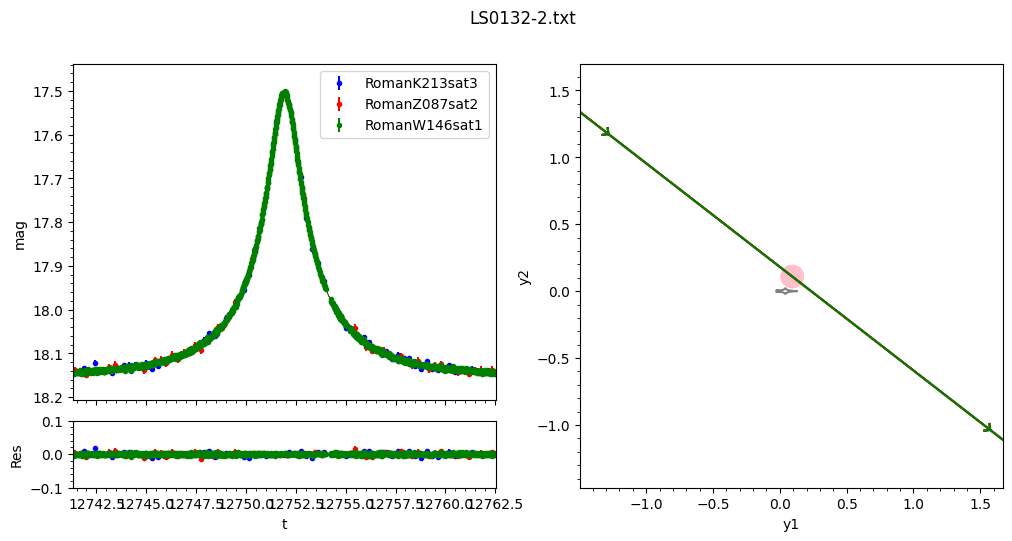

╒════════╤════════════════════════╕
│ chi2   │ 7015.140124114179      │
╞════════╪════════════════════════╡
│ s      │ 1.021 +- 0.010         │
├────────┼────────────────────────┤
│ q      │ 0.0002666 +- 0.0000052 │
├────────┼────────────────────────┤
│ u0     │ 0.14319 +- 0.00061     │
├────────┼────────────────────────┤
│ alpha  │ 2.4832 +- 0.0054       │
├────────┼────────────────────────┤
│ rho    │ 0.0821 +- 0.0020       │
├────────┼────────────────────────┤
│ tE     │ 5.301 +- 0.012         │
├────────┼────────────────────────┤
│ t0     │ 12751.92017 +- 0.00042 │
╘════════╧════════════════════════╛

╒═══════════════╤═══════════════════════╤════════════════╕
│ telescope     │ baseline              │ blending       │
╞═══════════════╪═══════════════════════╪════════════════╡
│ RomanK213sat3 │ 18.151876 +- 0.000019 │ 6.736 +- 0.026 │
├───────────────┼───────────────────────┼────────────────┤
│ RomanZ087sat2 │ 19.436695 +- 0.000026 │ 4.410 +- 0.019 │
├───────────────┼────────────────

In [2]:
import glob
import RTModel.plotmodel as plm

root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople'
eventname = root_dir+'/event_data_chris/event_000002'
models = glob.glob(eventname +'/FinalModels/*')
model = models[0] # let's plot the first of the best models

myplot = plm.plotmodel(eventname = eventname, modelfile = model)

From here, if for some reason you still haven't given up, you can run MCMC, or be done and try to map your "good" models to what they actually are in {s,q,alpha} space. 

#### The end! (for now)